## 1. Import Libraries

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [ ]:
df = pd.read_csv('house_prices.csv')

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Inspection

In [3]:
print('Data types:')
display(df.dtypes.to_frame('Data Type').head(20))

print('Summary statistics:')
display(df.describe().T)

Data types:


,Data Type
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
Alley,object
LotShape,object
LandContour,object
Utilities,object


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 4. Feature Selection

In [4]:
target = 'SalePrice'

features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageCars',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt'
]

required_columns = features + [target]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

X = df[features].copy()
y = df[target].copy()

print('Selected features:', features)
print('Target:', target)

Selected features: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt']
Target: SalePrice


## 5. Missing-Value Analysis

In [5]:
missing_summary = X.isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame('Missing Values'))
print(f'Missing target values: {y.isna().sum()}')

,Missing Values
OverallQual,0
GrLivArea,0
TotalBsmtSF,0
GarageCars,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


Missing target values: 0


## 6. Prepare the Target

In [6]:
valid_target = y.notna()
X = X.loc[valid_target].copy()
y = y.loc[valid_target].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1460, 7)
y shape: (1460,)


## 7. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training rows: {len(X_train):,}')
print(f'Testing rows:  {len(X_test):,}')

Training rows: 1,168
Testing rows:  292


## 8. Build the Preprocessing and Modeling Pipeline

In [8]:
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accou

## 9. Train the Model

In [9]:
model_pipeline.fit(X_train, y_train)
print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


## 10. Generate Predictions

In [10]:
y_pred = model_pipeline.predict(X_test)
print(f'Generated {len(y_pred):,} test-set predictions.')

Generated 292 test-set predictions.


## 11. Model Evaluation

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Value': [mae, rmse, r2]
})
display(metrics)

print(f'MAE: ${mae:,.2f}')
print(f'RMSE: ${rmse:,.2f}')
print(f'R² Score: {r2:.4f}')

,Metric,Value
0,MAE,25318.956432
1,RMSE,39715.991294
2,R² Score,0.794356


MAE: $25,318.96
RMSE: $39,715.99
R² Score: 0.7944


## 12. Actual vs. Predicted Prices

,Actual Price,Predicted Price,Absolute Error
0,154500,143477.571316,11022.428684
1,325000,295808.215990,29191.784010
2,115000,122144.157587,7144.157587
3,159000,177248.119595,18248.119595
4,315500,287889.564622,27610.435378
5,75500,56683.489875,18816.510125
6,311500,210500.145049,100999.854951
7,146000,173763.969229,27763.969229
8,84500,55980.272918,28519.727082
9,135500,131278.945587,4221.054413


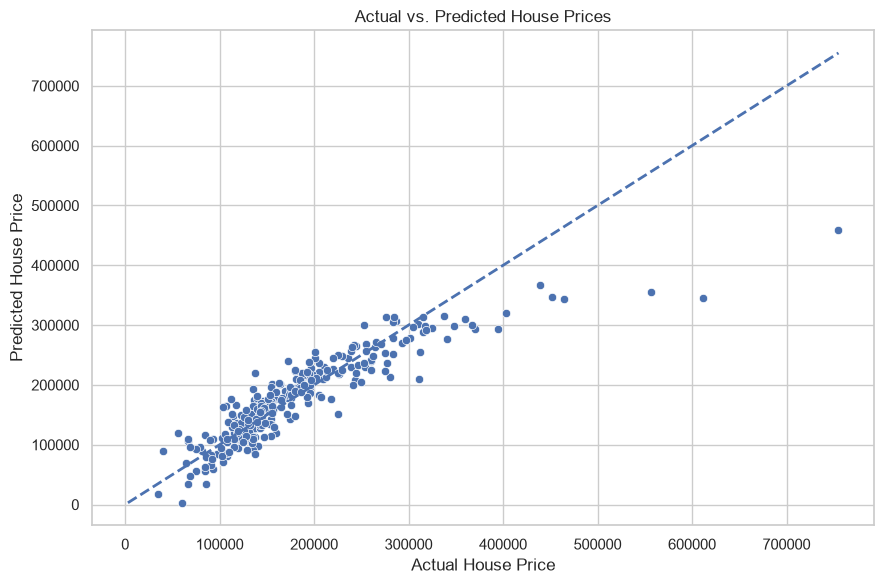

In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred,
})
comparison['Absolute Error'] = (comparison['Actual Price'] - comparison['Predicted Price']).abs()
display(comparison.head(10))

plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred)
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--',
    linewidth=2
)
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs. Predicted House Prices')
plt.tight_layout()
plt.show()

## 13. Residual Analysis

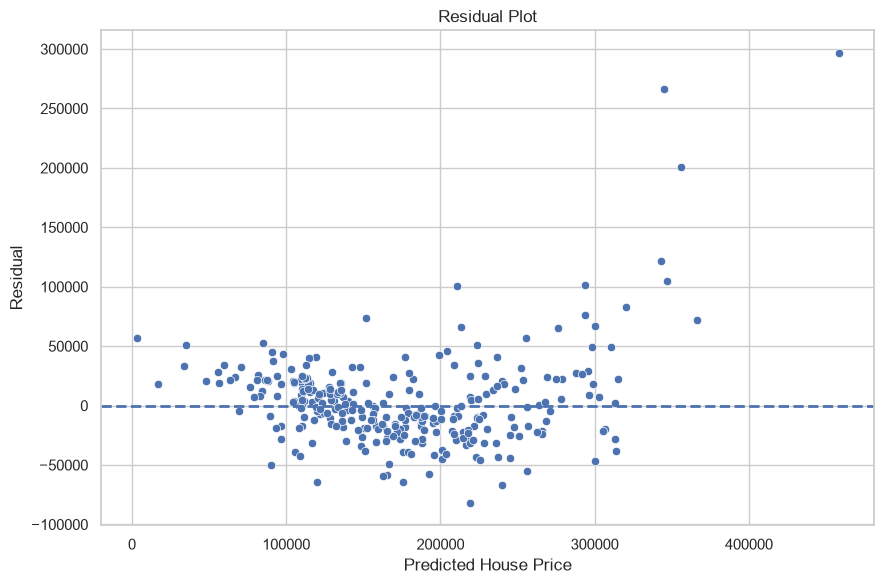

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--', linewidth=2)
plt.xlabel('Predicted House Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 14. Feature Coefficients

In [14]:
linear_model = model_pipeline.named_steps['model']

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})
coefficients['Absolute Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Absolute Coefficient', ascending=False)
display(coefficients)

,Feature,Coefficient,Absolute Coefficient
0,OverallQual,28046.387868,28046.387868
1,GrLivArea,27039.497094,27039.497094
3,GarageCars,11333.475474,11333.475474
2,TotalBsmtSF,10805.366989,10805.366989
6,YearBuilt,10781.145828,10781.145828
4,FullBath,-2995.570024,2995.570024
5,TotRmsAbvGrd,265.000936,265.000936


## 15. Feature Coefficient Visualization

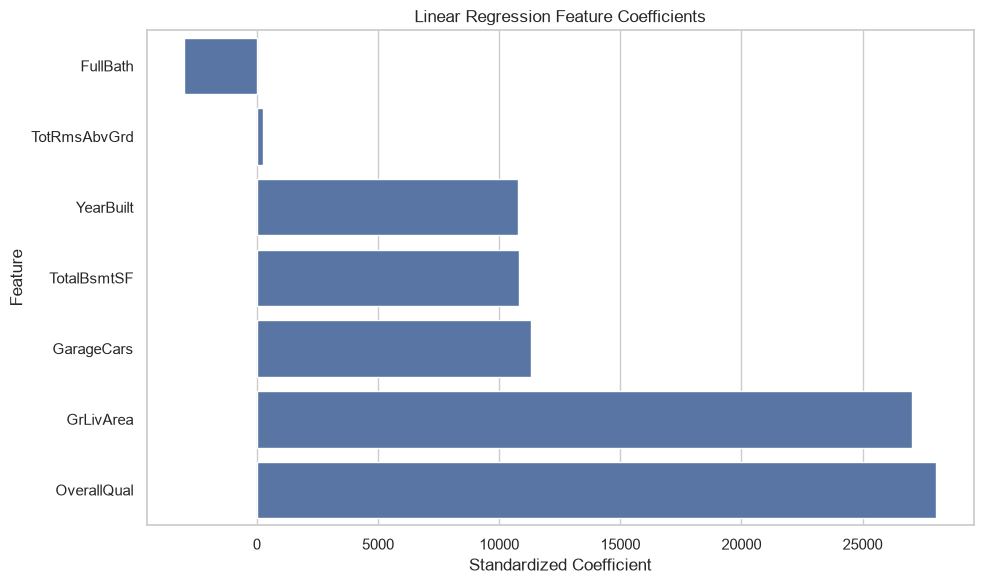

In [15]:
plot_data = coefficients.sort_values('Coefficient')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Coefficient', y='Feature')
plt.title('Linear Regression Feature Coefficients')
plt.xlabel('Standardized Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 16. Sale Price Distribution

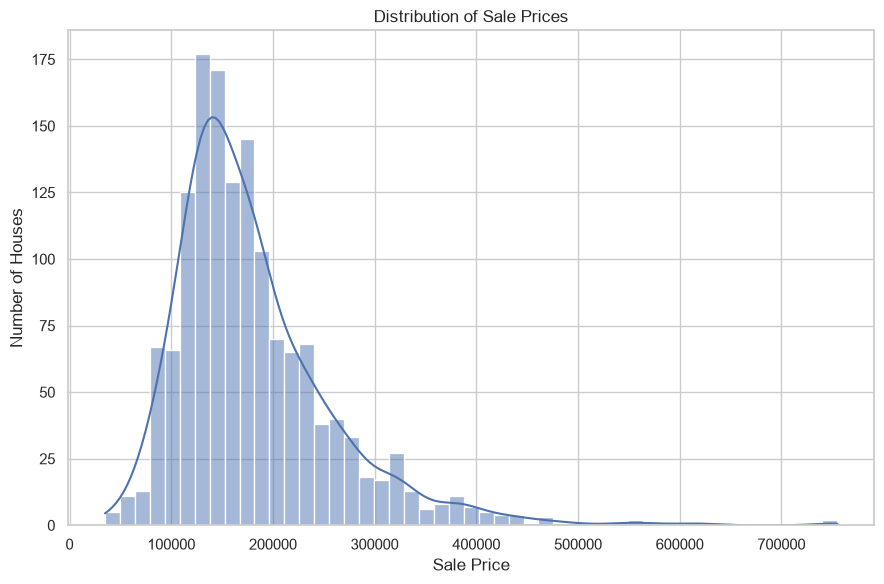

In [16]:
plt.figure(figsize=(9, 6))
sns.histplot(df[target].dropna(), kde=True)
plt.xlabel('Sale Price')
plt.ylabel('Number of Houses')
plt.title('Distribution of Sale Prices')
plt.tight_layout()
plt.show()

## 17. Correlation Analysis

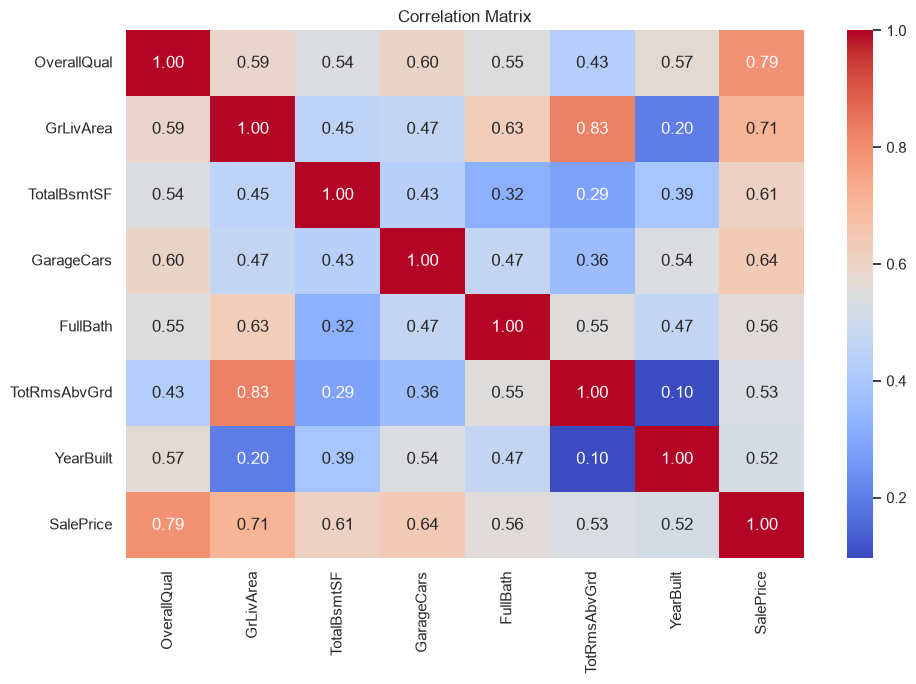

In [17]:
correlation = df[features + [target]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 18. Example Prediction

In [18]:
sample_house = pd.DataFrame([{
    'OverallQual': 7,
    'GrLivArea': 1710,
    'TotalBsmtSF': 856,
    'GarageCars': 2,
    'FullBath': 2,
    'TotRmsAbvGrd': 8,
    'YearBuilt': 2003
}])

predicted_price = float(model_pipeline.predict(sample_house)[0])
print(f'Predicted House Price: ${predicted_price:,.2f}')

Predicted House Price: $216,360.36
